# Articulated Flexible Drillpipe Analysis

This notebook analyzes the axial force, torque, joint articulation, and contact-force response of an Articulated Flexible Drillpipe in an ultra-short-radius horizontal well with a 2.7 m build-up radius.

The plots summarize simulation snapshots for `t >= 7 s`, using the median response and the 5th-95th percentile range.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scienceplots

In [2]:
import os

data_dir = os.path.join('data', 'ARC_FULL')

pipe_load_profile_path = os.path.join(data_dir, 'pipe_load_profile.csv')
contact_force_path = os.path.join(data_dir, 'contact_force.csv')
joint_articulation_path = os.path.join(data_dir, 'joint_articulation.csv')

## Data and time window

The analysis uses the three local CSV outputs listed above. Results are filtered to `t >= 7 s` to focus on the settled response after the initial transient.

In [3]:
plt.style.use(["notebook", "grid"])

In [4]:
pipe_load_profile = pd.read_csv(pipe_load_profile_path)
pipe_load_profile_late = pipe_load_profile[pipe_load_profile['Time_s'] >= 7]

In [5]:
def classify_segment(idx):
    if 0 <= idx < 17:
        return "Horizontal"
    elif 17 <= idx < 43:
        return "Build-up"
    else:
        return "Vertical"

# Apply to both pipe_load_profile and pipe_load_profile_late
pipe_load_profile['Segment'] = pipe_load_profile['JointIdx'].apply(classify_segment)
pipe_load_profile_late['Segment'] = pipe_load_profile_late['JointIdx'].apply(classify_segment)

## Well trajectory sections

Joint indices are grouped into the horizontal, build-up, and vertical sections of the simulated trajectory. Colors in the figures identify these sections.

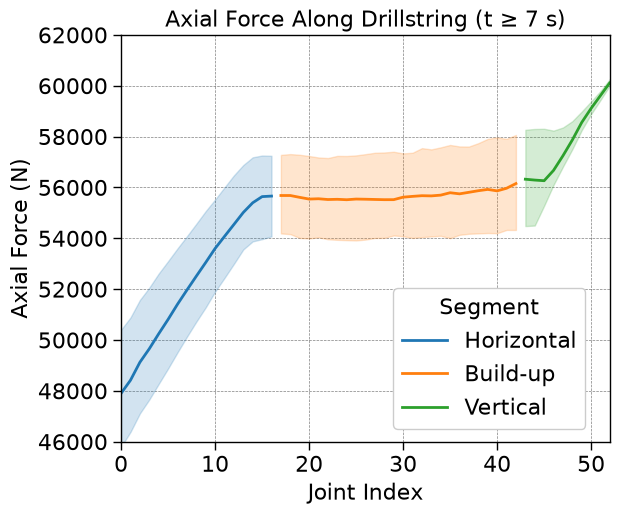

In [6]:
g = sns.relplot(
    data=pipe_load_profile_late,
    x="JointIdx",
    y="Axial_N",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32  # set figure aspect ratio
)

# grab the current Axes object
ax = g.axes.flat[0]

# show the top and right spines
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.7, 0.15))
    g.legend.set_loc("lower right")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

ax.set_xlabel("Joint Index")
ax.set_ylabel("Axial Force (N)")
ax.set_title("Axial Force Along Drillstring (t ≥ 7 s)")
plt.ylim(46000, 62000)
plt.xlim(0, 52)
plt.show()

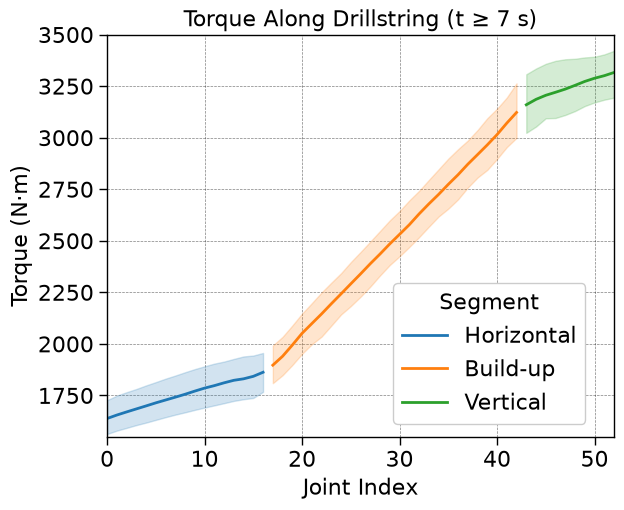

In [7]:
g = sns.relplot(
    data=pipe_load_profile_late,
    x="JointIdx",
    y="Torque_Nm",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32  # set figure aspect ratio
)

# grab the current Axes object
ax = g.axes.flat[0]

# show the top and right spines
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.7, 0.15))
    g.legend.set_loc("lower right")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

ax.set_xlabel("Joint Index")
ax.set_ylabel("Torque (N·m)")
ax.set_title("Torque Along Drillstring (t ≥ 7 s)")
plt.ylim(1550, 3500)
plt.xlim(0, 52)

plt.show()

In [8]:
joint_articulation_df = pd.read_csv(joint_articulation_path)
joint_articulation_df_late = joint_articulation_df[joint_articulation_df['Time_s'] >= 7]

joint_articulation_df['Segment'] = joint_articulation_df['JointIdx'].apply(classify_segment)
joint_articulation_df_late['Segment'] = joint_articulation_df_late['JointIdx'].apply(classify_segment)

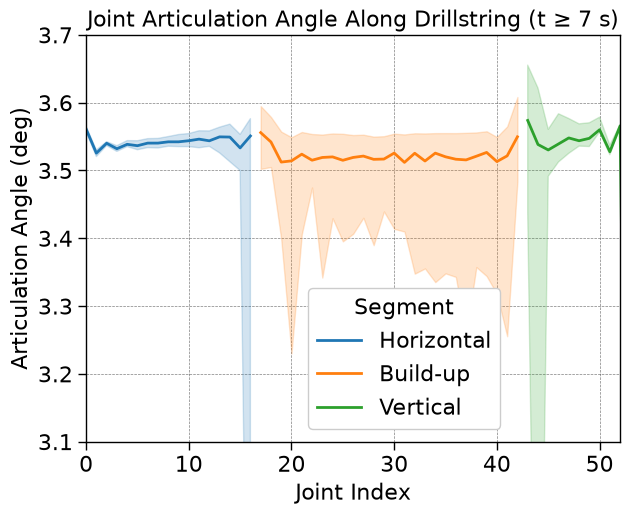

In [9]:
g = sns.relplot(
    data=joint_articulation_df_late,
    x="JointIdx",
    y="Angle_deg",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32  # set figure aspect ratio
)

# grab the current Axes object
ax = g.axes.flat[0]

# show the top and right spines
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.6, 0.15))
    g.legend.set_loc("lower right")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

ax.set_xlabel("Joint Index")
ax.set_ylabel("Articulation Angle (deg)")
ax.set_title("Joint Articulation Angle Along Drillstring (t ≥ 7 s)")
plt.ylim(3.1, 3.7)
plt.xlim(0, 52)
plt.show()

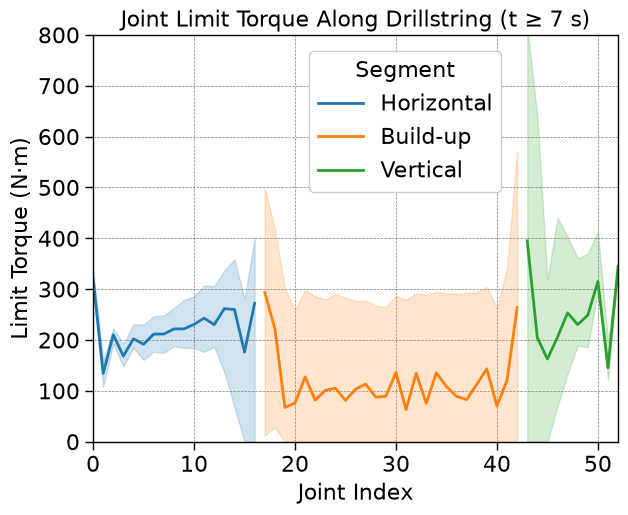

In [10]:
g = sns.relplot(
    data=joint_articulation_df_late,
    x="JointIdx",
    y="LimitTorque_Nm",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32  # set figure aspect ratio
)

# grab the current Axes object
ax = g.axes.flat[0]

# show the top and right spines
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.35, 0.95))
    g.legend.set_loc("upper left")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

ax.set_xlabel("Joint Index")
ax.set_ylabel("Limit Torque (N·m)")
ax.set_title("Joint Limit Torque Along Drillstring (t ≥ 7 s)")
plt.ylim(0, 800)
plt.xlim(0, 52)
plt.show()

In [11]:
contact_force_df = pd.read_csv(contact_force_path)
contact_force_df['Fn_N'] = np.sqrt(contact_force_df['FnX']**2 + contact_force_df['FnY']**2 + contact_force_df['FnZ']**2)

# number contacts from 0 within each Time_s group (preserves original row order)
contact_force_df['ContactIdx'] = contact_force_df.groupby('Time_s').cumcount()

contact_force_df['Segment'] = contact_force_df['SegIdx'].apply(classify_segment)

# slice to t >= 7 only after all derived columns exist, so ContactIdx / Segment carry over
contact_force_df_late = contact_force_df[contact_force_df['Time_s'] >= 7].copy()

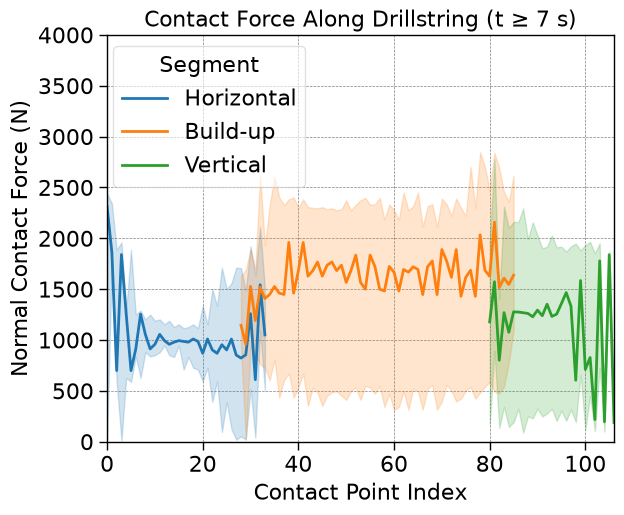

In [12]:
g = sns.relplot(
    data=contact_force_df_late,
    x="ContactIdx",
    y="Fn_N",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32  # set figure aspect ratio
)

# grab the current Axes object
ax = g.axes.flat[0]

# show the top and right spines
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.12, 0.96))
    g.legend.set_loc("upper left")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(0.6)

ax.set_xlabel("Contact Point Index")
ax.set_ylabel("Normal Contact Force (N)")
ax.set_title("Contact Force Along Drillstring (t ≥ 7 s)")
plt.ylim(0, 4000)
plt.xlim(0, 106)
plt.show()